# 04 - Análisis Bivariado: ¿Qué determina el costo de un viaje?

## Fase 2 del proyecto NYC Taxi

En este notebook exploramos las **relaciones entre variables** para entender qué factores influyen en el costo de un viaje en taxi en Nueva York.

### Objetivos de aprendizaje
- Construir e interpretar **scatter plots** para identificar relaciones entre variables continuas
- Calcular e interpretar la **matriz de correlación de Pearson**
- Realizar **análisis por segmentos** (Manhattan vs aeropuerto, día vs noche)
- Usar **regplot** de seaborn para ajustar líneas de regresión

### Concepto clave
El análisis bivariado estudia la relación entre **dos variables** simultáneamente. A diferencia del análisis univariado (notebook 03), aquí buscamos patrones de asociación, correlación y causalidad potencial.

---
## 1. Carga de datos y preparación

Cargamos una muestra limpia con columnas derivadas (zonas, hora, día de la semana, etc.) que creamos en la fase anterior.

In [1]:
import sys
sys.path.insert(0, '../../../src')
from bigquery.bq_helper import BigQueryHelper
bq = BigQueryHelper()

✓ Conectado a BigQuery - Proyecto: gen-lang-client-0180273702
✓ Cache en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/nyc_taxi/cache


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
# Definición de zonas TLC por location_id
MANHATTAN_ZONES = (
    "'4','12','13','24','41','42','43','45','48','50','68','74','75','79','87','88','90',"
    "'100','107','113','114','116','125','127','128','137','140','141','142','143','144',"
    "'148','151','152','153','158','161','162','163','164','166','170','186','194','202',"
    "'209','211','224','229','230','231','232','233','234','236','237','238','239','243',"
    "'244','246','249','261','262','263'"
)

BROOKLYN_ZONES = (
    "'11','14','17','21','22','25','26','29','33','34','35','36','37','39','40','49','52',"
    "'54','55','61','62','63','65','66','67','69','71','72','76','77','80','85','89','91',"
    "'97','106','108','111','112','123','133','149','150','154','155','165','177','178',"
    "'181','188','189','190','195','210','217','222','225','227','228','255','256','257'"
)

# Consulta: muestra limpia con columnas derivadas y zonas basadas en location_id
query_sample = f"""
SELECT
    pickup_datetime,
    dropoff_datetime,
    pickup_location_id,
    dropoff_location_id,
    passenger_count,
    trip_distance,
    fare_amount,
    tip_amount,
    tolls_amount,
    total_amount,
    payment_type,
    EXTRACT(HOUR FROM pickup_datetime) AS pickup_hour,
    EXTRACT(DAYOFWEEK FROM pickup_datetime) AS day_of_week,
    TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, MINUTE) AS trip_duration_min,
    -- Clasificación de zona de recogida por location_id
    CASE
        WHEN pickup_location_id = '132' THEN 'JFK'
        WHEN pickup_location_id = '138' THEN 'LaGuardia'
        WHEN pickup_location_id = '1'   THEN 'Newark'
        WHEN pickup_location_id IN ({MANHATTAN_ZONES}) THEN 'Manhattan'
        WHEN pickup_location_id IN ({BROOKLYN_ZONES}) THEN 'Brooklyn'
        ELSE 'Otra'
    END AS pickup_zone,
    -- Tarifa por milla
    SAFE_DIVIDE(fare_amount, trip_distance) AS fare_per_mile,
    -- Porcentaje de propina
    SAFE_DIVIDE(tip_amount, fare_amount) * 100 AS tip_percentage
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`
WHERE
    fare_amount BETWEEN 2.5 AND 200
    AND trip_distance BETWEEN 0.1 AND 50
    AND passenger_count BETWEEN 1 AND 6
    AND TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, MINUTE) BETWEEN 1 AND 180
ORDER BY RAND()
LIMIT 30000
"""

df = bq.query(query_sample)
print(f"Registros cargados: {len(df):,}")
df.head()

📊 Estimación: 15.855 GB → $0.0968 USD
⏳ Ejecutando query...
✓ Completado: 30,000 filas en 7.0s
💾 Cache guardado: dc413c0b82ec.parquet (1.0 MB)
Registros cargados: 30,000


,pickup_datetime,dropoff_datetime,pickup_location_id,dropoff_location_id,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,payment_type,pickup_hour,day_of_week,trip_duration_min,pickup_zone,fare_per_mile,tip_percentage
0,2015-10-07 13:27:28+00:00,2015-10-07 13:38:30+00:00,237,75,1,1.79,9.5,0.0,0.0,10.3,2,13,4,11,Manhattan,5.307263,0.00000
1,2015-10-12 16:11:59+00:00,2015-10-12 16:14:09+00:00,237,236,1,0.42,3.5,0.0,0.0,4.3,2,16,2,2,Manhattan,8.333333,0.00000
2,2015-04-05 17:39:51+00:00,2015-04-05 17:46:12+00:00,41,42,2,1.06,6.5,0.0,0.0,7.3,2,17,1,6,Manhattan,6.132075,0.00000
3,2015-12-04 19:42:43+00:00,2015-12-04 19:59:03+00:00,68,239,1,2.50,12.0,1.5,0.0,14.8,1,19,6,16,Manhattan,4.800000,12.50000
4,2015-04-04 22:28:02+00:00,2015-04-04 22:39:20+00:00,100,79,1,1.90,9.5,3.2,0.0,14.0,1,22,7,11,Manhattan,5.000000,33.68421


In [4]:
# Resumen rápido de las variables numéricas
numeric_cols = ['trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount',
                'total_amount', 'trip_duration_min', 'fare_per_mile', 'tip_percentage']
df[numeric_cols].describe().round(2)

,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,trip_duration_min,fare_per_mile,tip_percentage
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.0,30000.00,30000.00
mean,2.99,12.81,1.70,0.30,15.93,13.55,5.81,13.31
std,3.60,10.26,2.65,1.35,12.72,10.83,2.90,14.30
min,0.10,2.50,0.00,0.00,3.30,1.0,0.30,0.00
25%,1.04,6.50,0.00,0.00,8.76,6.0,4.17,0.00
50%,1.75,9.50,1.20,0.00,11.80,11.0,5.29,15.38
75%,3.20,14.50,2.30,0.00,17.80,17.0,6.75,22.50
max,40.86,152.00,200.00,23.50,223.30,173.0,173.33,909.09


---
## 2. Scatter plot: distancia vs tarifa

La relación más intuitiva: ¿viajes más largos cuestan más?

### Nota técnica
Usamos `alpha` (transparencia) para manejar el **overplotting** — cuando hay tantos puntos que se superponen y no se puede ver la densidad real. Un alpha bajo (0.1-0.3) permite ver dónde se concentran más los datos.

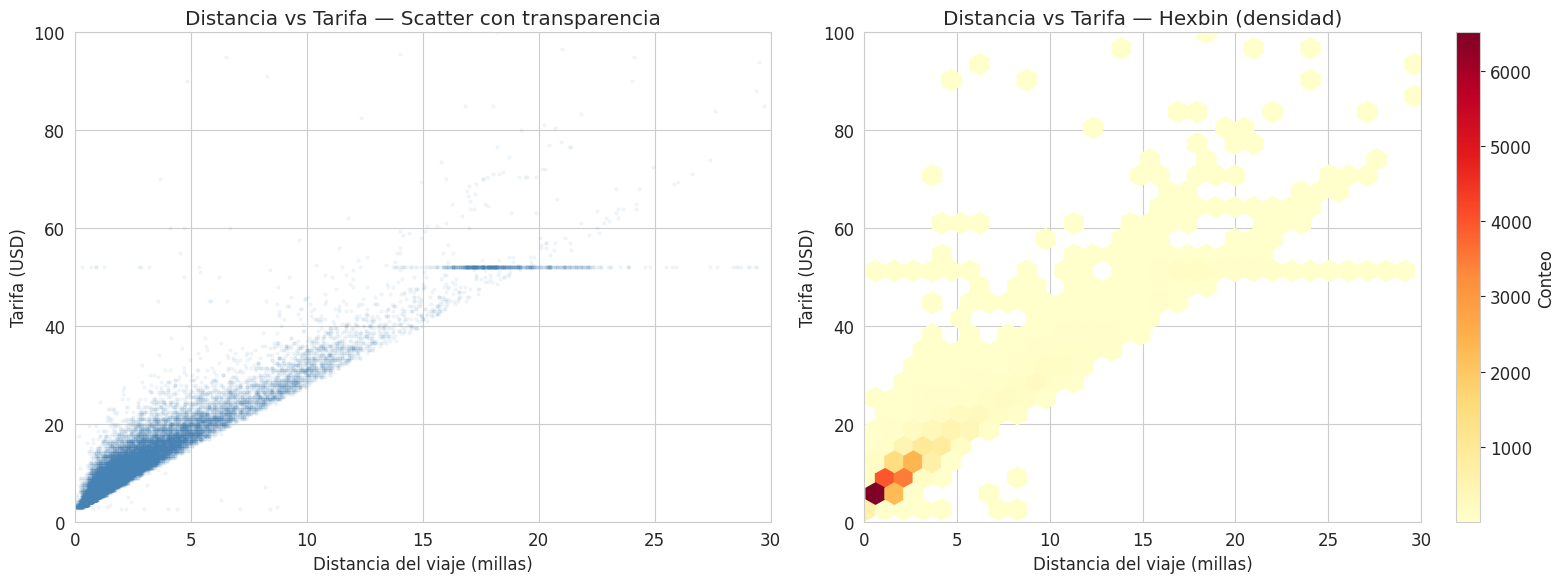


Correlación de Pearson (distancia vs tarifa): 0.9519


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter básico con alpha
axes[0].scatter(df['trip_distance'], df['fare_amount'],
                alpha=0.05, s=5, color='steelblue')
axes[0].set_xlabel('Distancia del viaje (millas)')
axes[0].set_ylabel('Tarifa (USD)')
axes[0].set_title('Distancia vs Tarifa — Scatter con transparencia')
axes[0].set_xlim(0, 30)
axes[0].set_ylim(0, 100)

# Scatter con hexbin para densidad
hb = axes[1].hexbin(df['trip_distance'], df['fare_amount'],
                     gridsize=40, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('Distancia del viaje (millas)')
axes[1].set_ylabel('Tarifa (USD)')
axes[1].set_title('Distancia vs Tarifa — Hexbin (densidad)')
axes[1].set_xlim(0, 30)
axes[1].set_ylim(0, 100)
plt.colorbar(hb, ax=axes[1], label='Conteo')

plt.tight_layout()
plt.show()

# Correlación puntual
corr = df['trip_distance'].corr(df['fare_amount'])
print(f"\nCorrelación de Pearson (distancia vs tarifa): {corr:.4f}")

**Interpretación:**
- La relación es claramente **positiva y lineal** en la mayor parte del rango
- El hexbin revela que la mayor densidad está en viajes cortos (< 5 millas, < $20)
- Se observan algunas líneas horizontales: esas corresponden a **tarifas fijas** (ej: tarifa fija al aeropuerto JFK = $52)

---
## 3. Pair plot de variables numéricas clave

El **pair plot** (o scatter matrix) nos permite ver la relación entre todas las combinaciones de pares de variables a la vez. Es una herramienta exploratoria poderosa para identificar relaciones no obvias.

### Nota
Usamos un subconjunto de columnas para evitar un gráfico demasiado grande.

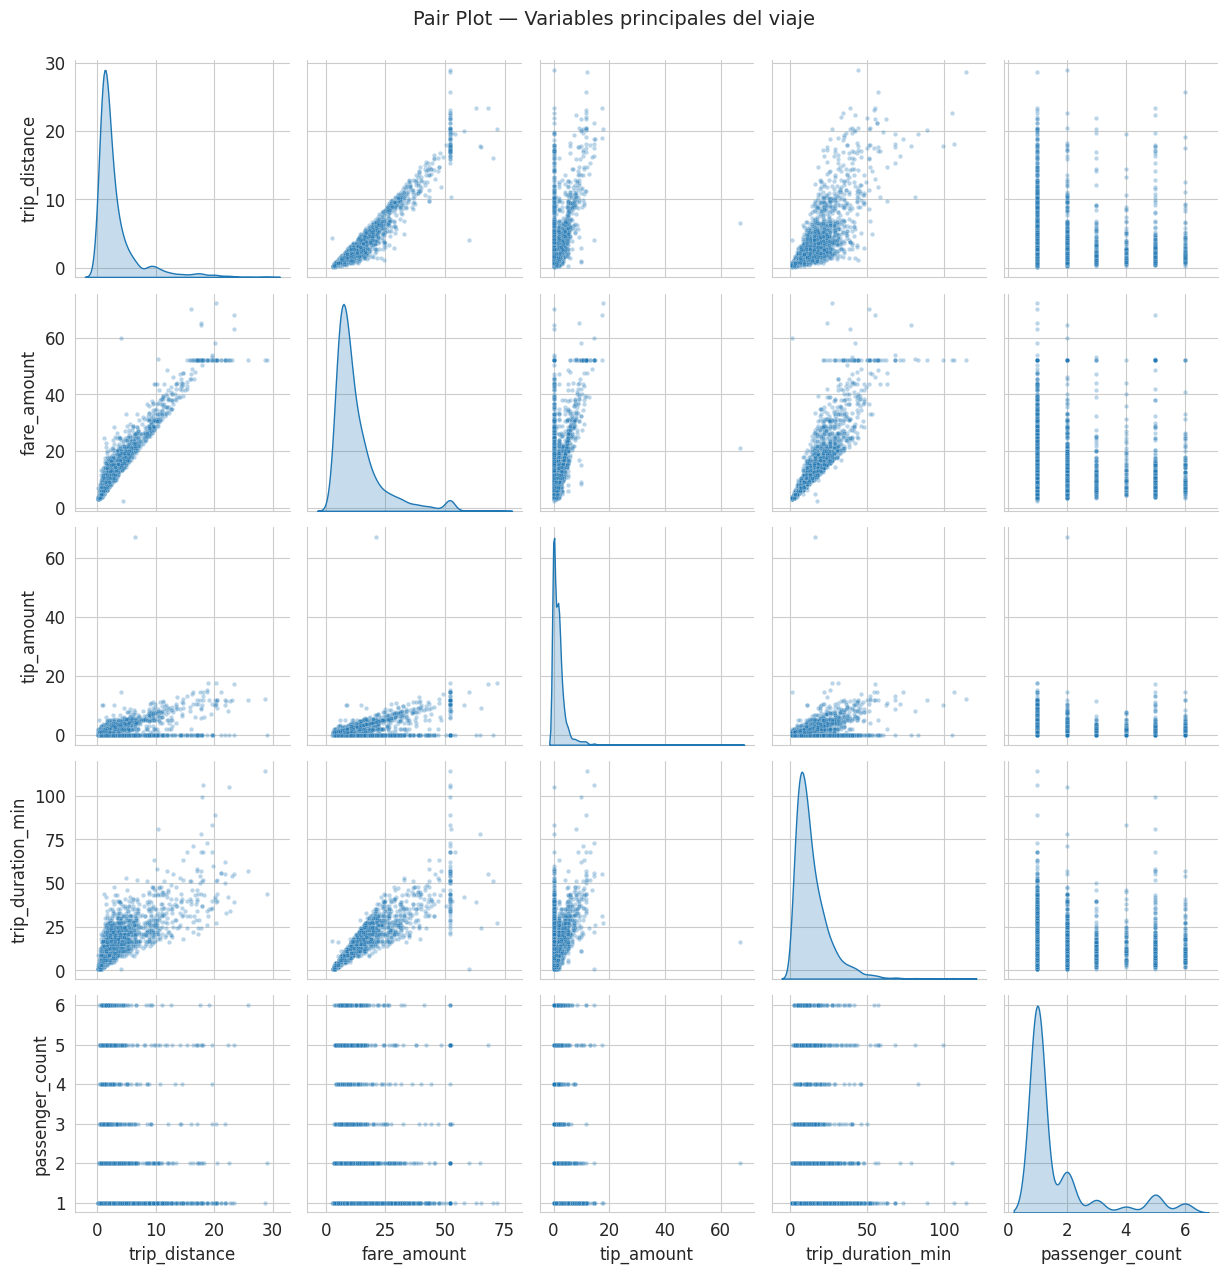

In [6]:
# Seleccionamos variables clave y una muestra para rendimiento
pairplot_cols = ['trip_distance', 'fare_amount', 'tip_amount',
                 'trip_duration_min', 'passenger_count']

df_pair = df[pairplot_cols].sample(n=3000, random_state=42)

g = sns.pairplot(df_pair, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10},
                 diag_kws={'fill': True})
g.figure.suptitle('Pair Plot — Variables principales del viaje', y=1.02, fontsize=14)
plt.show()

**Observaciones del pair plot:**
- `trip_distance` y `fare_amount` tienen la relación lineal más fuerte
- `trip_duration_min` también se relaciona con la tarifa, pero con más dispersión
- `passenger_count` no muestra relación clara con ninguna otra variable
- La diagonal (KDE) muestra las distribuciones univariadas de cada variable

---
## 4. Matriz de correlación de Pearson

La **correlación de Pearson** mide la fuerza y dirección de la relación **lineal** entre dos variables. Su valor va de -1 (relación negativa perfecta) a +1 (relación positiva perfecta). Un valor cercano a 0 indica ausencia de relación lineal.

### Precaución
Correlación **no implica causalidad**. Dos variables pueden estar correlacionadas sin que una cause a la otra (pueden compartir una causa común).

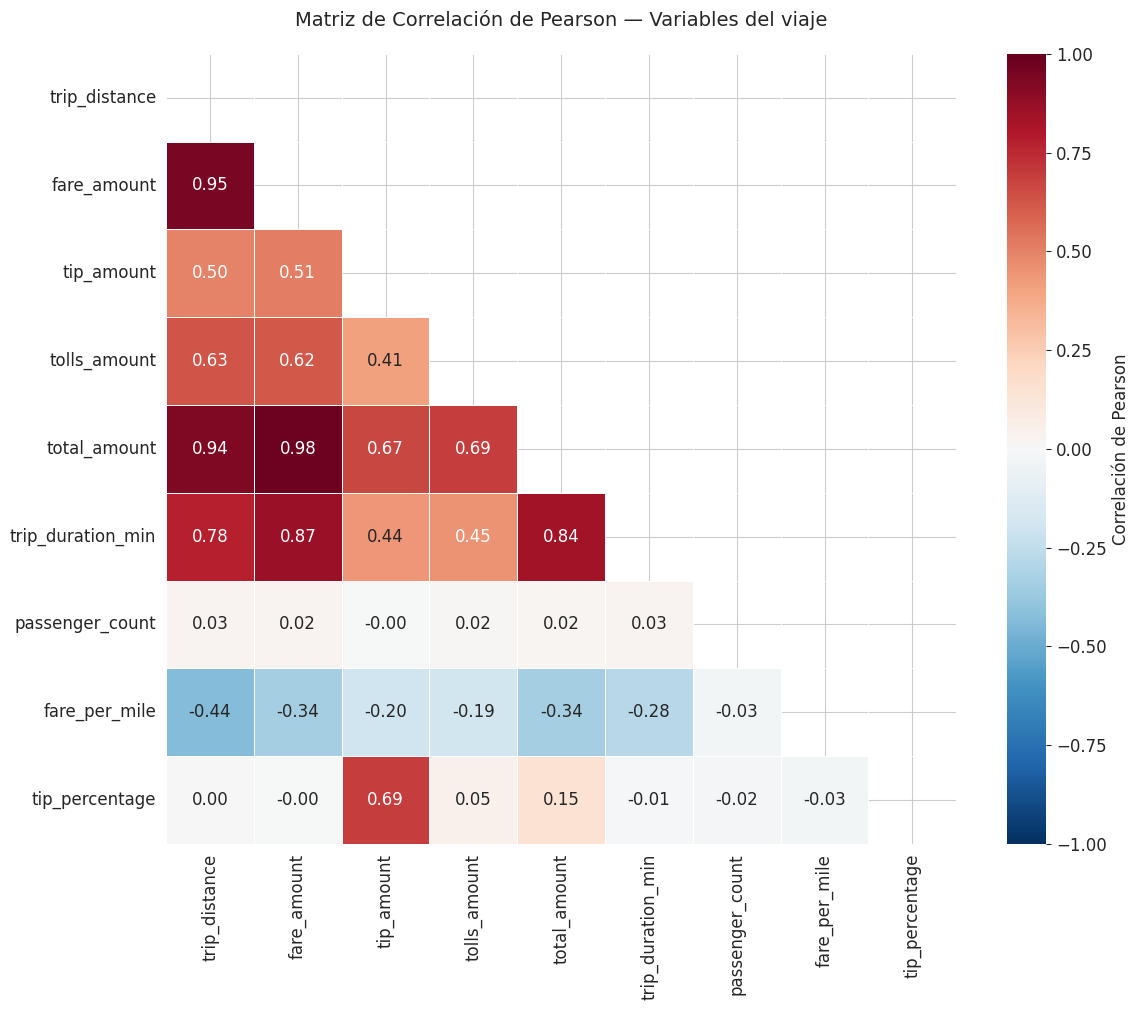

In [7]:
# Variables para la matriz de correlación
corr_cols = ['trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount',
             'total_amount', 'trip_duration_min', 'passenger_count',
             'fare_per_mile', 'tip_percentage']

corr_matrix = df[corr_cols].corr(method='pearson')

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior

sns.heatmap(corr_matrix.astype(float), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',            center=0, vmin=-1, vmax=1, linewidths=0.5,
            square=True, ax=ax,
            cbar_kws={'label': 'Correlación de Pearson'})

ax.set_title('Matriz de Correlación de Pearson — Variables del viaje', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [8]:
# Top correlaciones (excluyendo la diagonal y duplicados)
corr_pairs = []
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        corr_pairs.append({
            'Variable 1': corr_cols[i],
            'Variable 2': corr_cols[j],
            'Correlación': corr_matrix.iloc[i, j]
        })

df_corr = pd.DataFrame(corr_pairs).sort_values('Correlación', key=abs, ascending=False)
print("Top 10 correlaciones más fuertes:")
df_corr.head(10)

Top 10 correlaciones más fuertes:


,Variable 1,Variable 2,Correlación
10,fare_amount,total_amount,0.977863
0,trip_distance,fare_amount,0.951912
3,trip_distance,total_amount,0.936135
11,fare_amount,trip_duration_min,0.866230
26,total_amount,trip_duration_min,0.836849
4,trip_distance,trip_duration_min,0.775104
21,tolls_amount,total_amount,0.693034
20,tip_amount,tip_percentage,0.691950
16,tip_amount,total_amount,0.667031
2,trip_distance,tolls_amount,0.630505


**Interpretación de la matriz:**
- **Correlaciones fuertes (>0.7):** `fare_amount` con `total_amount` (esperado, total incluye tarifa), `trip_distance` con `fare_amount`
- **Correlaciones moderadas (0.3-0.7):** `trip_duration_min` con `fare_amount`, `tip_amount` con `fare_amount`
- **Correlaciones débiles (<0.3):** `passenger_count` con casi todo — el número de pasajeros no afecta significativamente al costo

---
## 5. Análisis por segmentos: Manhattan vs Aeropuerto

Los viajes al aeropuerto tienen una estructura tarifaria diferente (tarifa fija a JFK). Comparamos los segmentos para ver cómo difiere la relación distancia-tarifa.

In [9]:
# Crear segmentos basados en pickup_zone (derivada de location_id)
df['segment'] = df['pickup_zone'].apply(
    lambda z: 'Aeropuerto' if z in ['JFK', 'LaGuardia', 'Newark']
    else ('Manhattan' if z == 'Manhattan' else 'Otro')
)

print("Distribución de segmentos:")
print(df['segment'].value_counts())
print()

Distribución de segmentos:
segment
Manhattan     27291
Otro           1413
Aeropuerto     1296
Name: count, dtype: int64



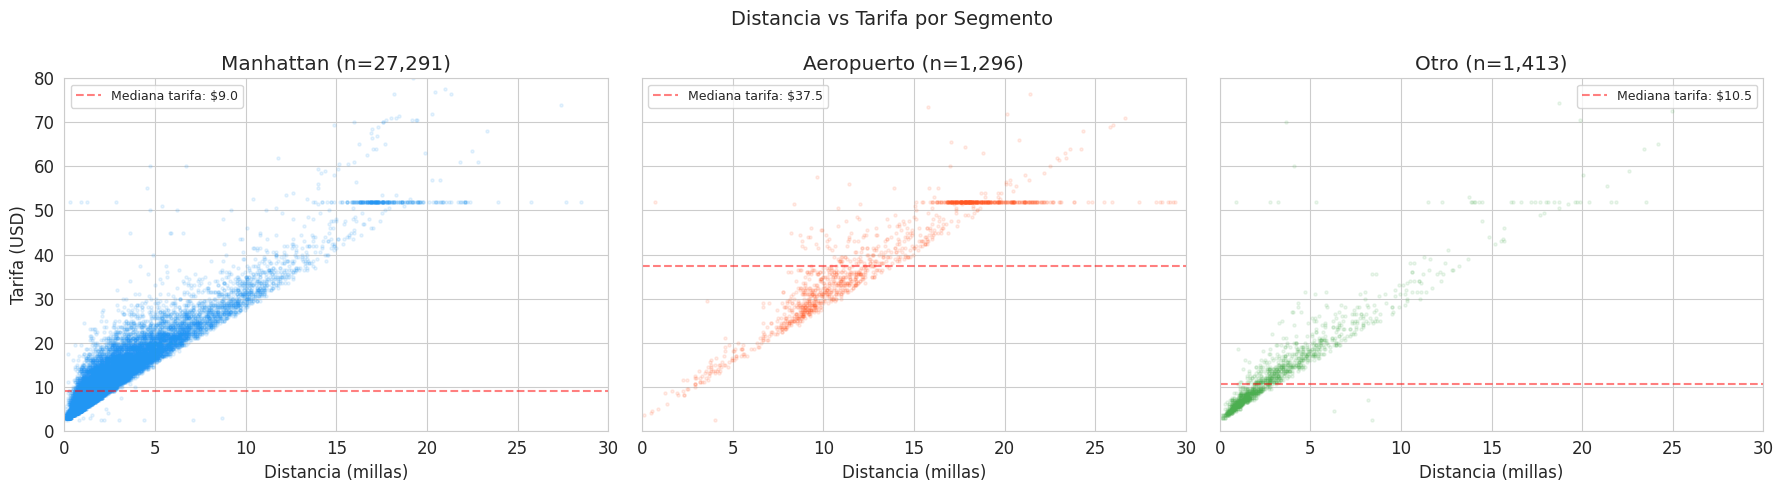

In [10]:
# Comparación visual por segmento
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
segments = ['Manhattan', 'Aeropuerto', 'Otro']
colors = ['#2196F3', '#FF5722', '#4CAF50']

for ax, seg, color in zip(axes, segments, colors):
    data = df[df['segment'] == seg]
    ax.scatter(data['trip_distance'], data['fare_amount'],
               alpha=0.1, s=5, color=color)
    ax.set_xlabel('Distancia (millas)')
    ax.set_title(f'{seg} (n={len(data):,})')
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 80)

    # Estadísticas
    median_fare = data['fare_amount'].median()
    median_dist = data['trip_distance'].median()
    ax.axhline(y=median_fare, color='red', linestyle='--', alpha=0.5,
               label=f'Mediana tarifa: ${median_fare:.1f}')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Tarifa (USD)')
fig.suptitle('Distancia vs Tarifa por Segmento', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Estadísticas comparativas por segmento
segment_stats = df.groupby('segment').agg(
    viajes=('fare_amount', 'count'),
    tarifa_media=('fare_amount', 'mean'),
    tarifa_mediana=('fare_amount', 'median'),
    distancia_media=('trip_distance', 'mean'),
    fare_per_mile_media=('fare_per_mile', 'median'),
    propina_pct_media=('tip_percentage', 'median')
).round(2)

print("Estadísticas por segmento:")
segment_stats

Estadísticas por segmento:


,viajes,tarifa_media,tarifa_mediana,distancia_media,fare_per_mile_media,propina_pct_media
segment,,,,,,
Aeropuerto,1296,38.86,37.5,13.05,3.00,17.31
Manhattan,27291,11.51,9.0,2.49,5.42,15.38
Otro,1413,14.05,10.5,3.47,4.71,11.89


**Hallazgos del análisis por segmento:**
- Los viajes desde **aeropuertos** tienden a ser más largos y más caros (tarifa fija JFK = $52)
- En el scatter de aeropuerto, se puede ver una **línea horizontal** clara en $52 — la tarifa plana a JFK
- Los viajes de **Manhattan** son en general más cortos pero con tarifa por milla más alta (tráfico, congestión)
- La tarifa por milla varía significativamente entre segmentos

---
## 6. Efecto del recargo nocturno

En NYC, los taxis amarillos aplican un **recargo nocturno de $0.50** entre las 8:00 PM y las 6:00 AM. ¿Se nota este efecto en los datos?

In [12]:
# Clasificar viajes en nocturnos y diurnos
df['is_night'] = df['pickup_hour'].apply(
    lambda h: 'Nocturno (8PM-6AM)' if (h >= 20 or h < 6) else 'Diurno (6AM-8PM)'
)

print("Distribución día/noche:")
print(df['is_night'].value_counts())
print()

Distribución día/noche:
is_night
Diurno (6AM-8PM)      19624
Nocturno (8PM-6AM)    10376
Name: count, dtype: int64



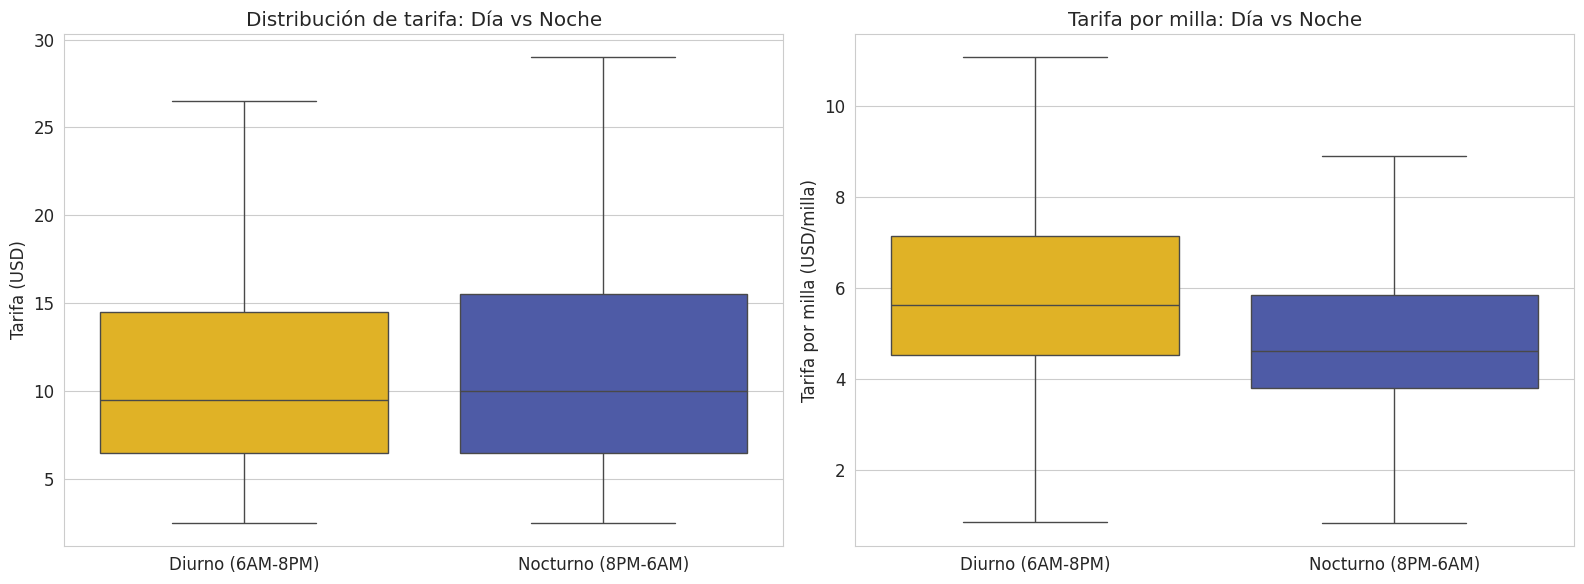

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot comparativo de tarifa
sns.boxplot(data=df, x='is_night', y='fare_amount', ax=axes[0],
            palette=['#FFC107', '#3F51B5'], showfliers=False)
axes[0].set_title('Distribución de tarifa: Día vs Noche')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tarifa (USD)')

# Box plot de tarifa por milla
df_filtered_fpm = df[df['fare_per_mile'].between(0, 20)]  # Filtrar outliers
sns.boxplot(data=df_filtered_fpm, x='is_night', y='fare_per_mile', ax=axes[1],
            palette=['#FFC107', '#3F51B5'], showfliers=False)
axes[1].set_title('Tarifa por milla: Día vs Noche')
axes[1].set_xlabel('')
axes[1].set_ylabel('Tarifa por milla (USD/milla)')

plt.tight_layout()
plt.show()

In [14]:
# Comparación estadística
night_comparison = df.groupby('is_night').agg(
    tarifa_media=('fare_amount', 'mean'),
    tarifa_mediana=('fare_amount', 'median'),
    fare_per_mile_mediana=('fare_per_mile', 'median'),
    distancia_media=('trip_distance', 'mean'),
    duracion_media=('trip_duration_min', 'mean'),
    propina_pct_media=('tip_percentage', 'median'),
    n_viajes=('fare_amount', 'count')
).round(2)

print("Comparación Día vs Noche:")
night_comparison

Comparación Día vs Noche:


,tarifa_media,tarifa_mediana,fare_per_mile_mediana,distancia_media,duracion_media,propina_pct_media,n_viajes
is_night,,,,,,,
Diurno (6AM-8PM),12.74,9.5,5.64,2.83,14.19,15.0,19624
Nocturno (8PM-6AM),12.95,10.0,4.62,3.30,12.33,16.0,10376


**Hallazgos sobre el recargo nocturno:**
- El recargo nocturno de $0.50 tiene un efecto modesto en la tarifa total
- Sin embargo, los viajes nocturnos tienden a ser **más rápidos** (menos tráfico), lo que puede compensar parcialmente el recargo
- La **tarifa por milla** es ligeramente diferente entre día y noche, reflejando tanto el recargo como la velocidad del tráfico

---
## 7. Tarifa por milla por zona y hora

¿Cómo varía el costo por milla según la zona de recogida y la hora del día? Esta métrica captura la eficiencia real del costo de transporte.

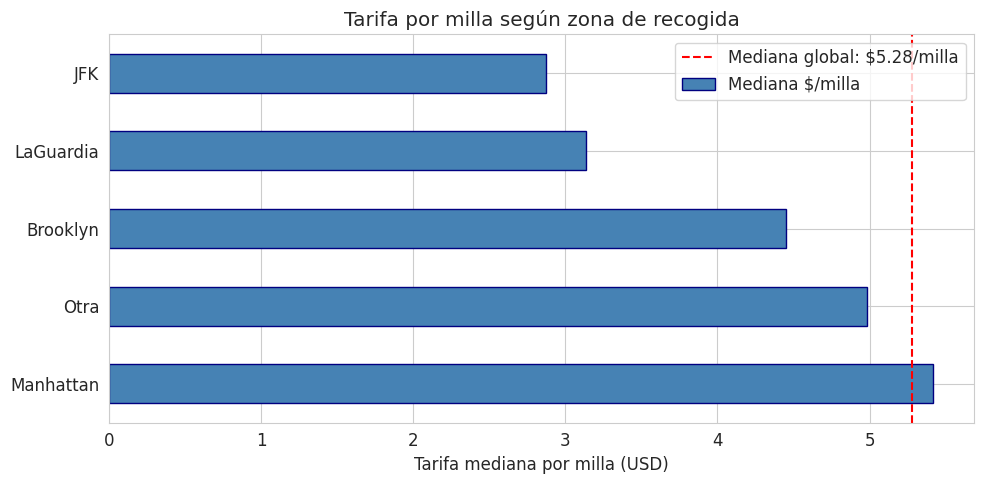


Detalle por zona:


,Mediana $/milla,Media $/milla,N viajes
pickup_zone,,,
Manhattan,5.42,5.87,27186
Otra,4.99,5.41,828
Brooklyn,4.45,4.83,580
LaGuardia,3.14,3.29,668
JFK,2.87,2.90,626


In [15]:
# Filtrar fare_per_mile razonable
df_fpm = df[(df['fare_per_mile'] > 0) & (df['fare_per_mile'] < 20)].copy()

# Tarifa por milla por zona
fpm_zone = df_fpm.groupby('pickup_zone')['fare_per_mile'].agg(['median', 'mean', 'count'])
fpm_zone = fpm_zone[fpm_zone['count'] >= 50].sort_values('median', ascending=False)
fpm_zone.columns = ['Mediana $/milla', 'Media $/milla', 'N viajes']

fig, ax = plt.subplots(figsize=(10, 5))
fpm_zone['Mediana $/milla'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='navy')
ax.set_xlabel('Tarifa mediana por milla (USD)')
ax.set_ylabel('')
ax.set_title('Tarifa por milla según zona de recogida')
ax.axvline(x=df_fpm['fare_per_mile'].median(), color='red', linestyle='--',
           label=f'Mediana global: ${df_fpm["fare_per_mile"].median():.2f}/milla')
ax.legend()
plt.tight_layout()
plt.show()

print("\nDetalle por zona:")
fpm_zone.round(2)

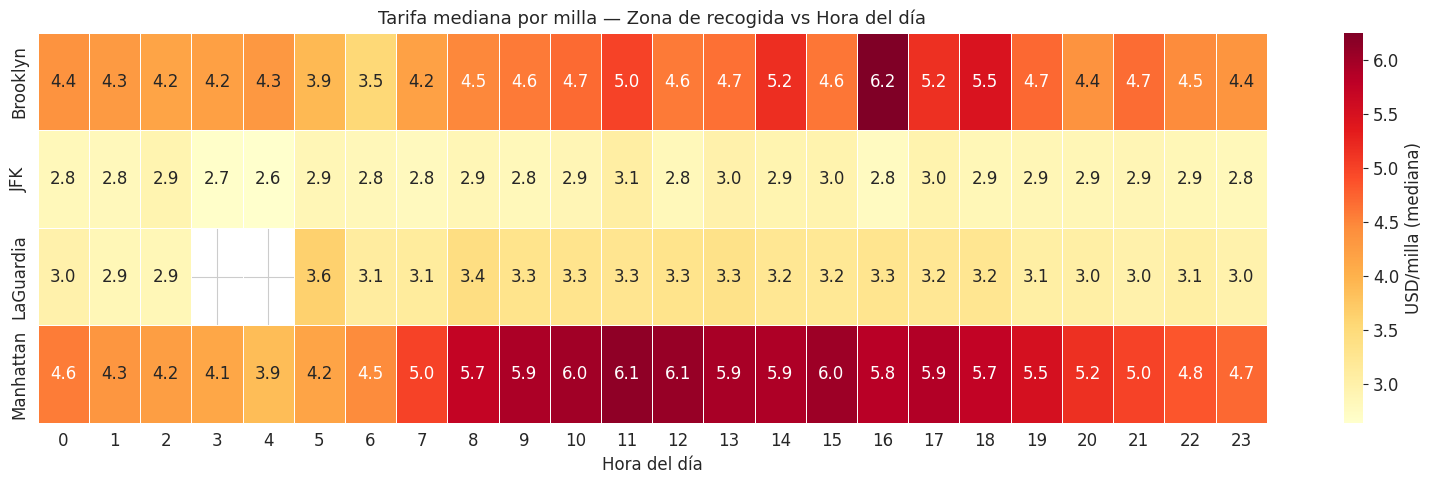

In [16]:
# Heatmap: tarifa por milla por zona y hora
main_zones = ['Manhattan', 'Brooklyn', 'JFK', 'LaGuardia']
df_main = df_fpm[df_fpm['pickup_zone'].isin(main_zones)]

pivot_fpm = df_main.pivot_table(
    values='fare_per_mile',
    index='pickup_zone',
    columns='pickup_hour',
    aggfunc='median'
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot_fpm.astype(float), cmap='YlOrRd', annot=True, fmt='.1f',            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'USD/milla (mediana)'})
ax.set_title('Tarifa mediana por milla — Zona de recogida vs Hora del día', fontsize=13)
ax.set_xlabel('Hora del día')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Observaciones:**
- **Manhattan** tiene la tarifa por milla más alta, especialmente en horas pico (tráfico = taxímetro corriendo más tiempo por milla)
- Los **aeropuertos** tienden a tener tarifa por milla más baja (viajes largos por autopista = más eficientes)
- Las **horas pico** (7-9 AM, 5-7 PM) muestran tarifas por milla elevadas en zonas de alto tráfico

---
## 8. Scatter con línea de regresión

Usamos `seaborn.regplot` para ajustar una **línea de regresión** al scatter plot. La banda sombreada muestra el **intervalo de confianza del 95%** para la línea de regresión.

### Concepto
La regresión lineal busca la recta que mejor ajusta los datos, minimizando la suma de errores cuadráticos. La pendiente de la recta nos dice cuánto cambia la variable Y (tarifa) por cada unidad de cambio en X (distancia).

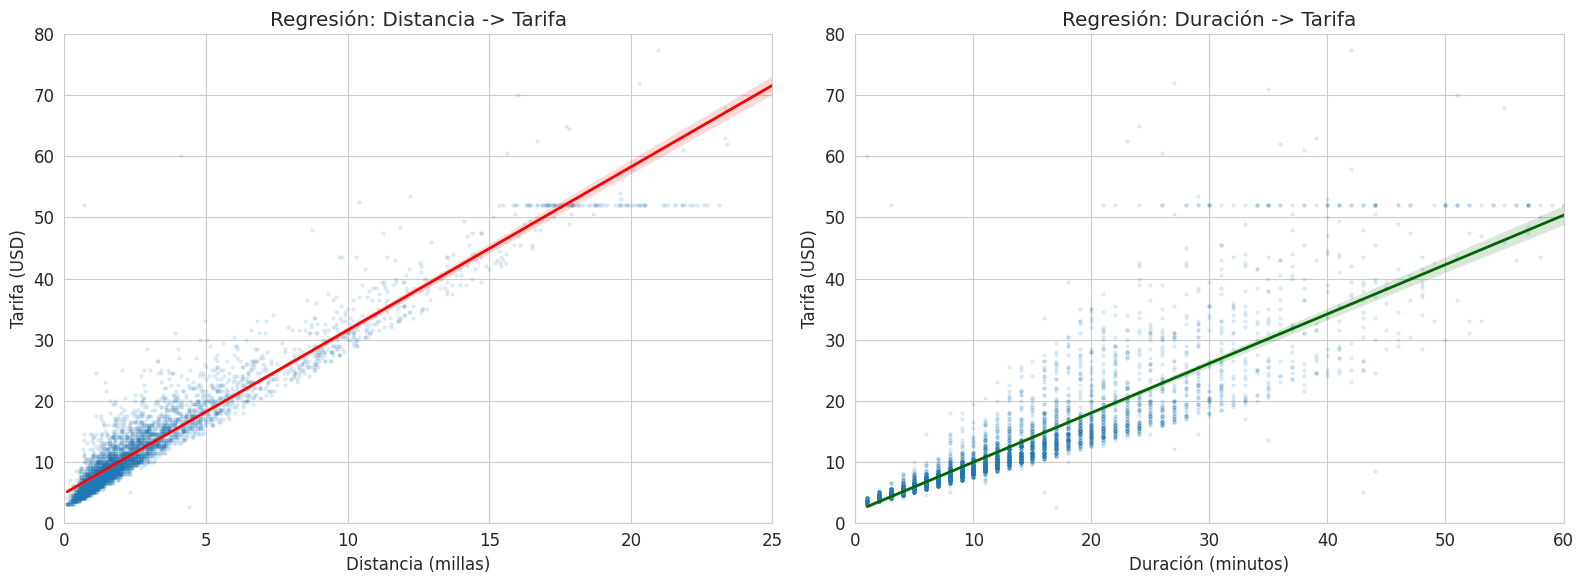

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regplot: distancia vs tarifa
sample_reg = df.sample(n=5000, random_state=42)

sns.regplot(data=sample_reg, x='trip_distance', y='fare_amount',
            scatter_kws={'alpha': 0.1, 's': 5},
            line_kws={'color': 'red', 'linewidth': 2},
            ci=95, ax=axes[0])
axes[0].set_xlim(0, 25)
axes[0].set_ylim(0, 80)
axes[0].set_title('Regresión: Distancia -> Tarifa')
axes[0].set_xlabel('Distancia (millas)')
axes[0].set_ylabel('Tarifa (USD)')

# Regplot: duración vs tarifa
sns.regplot(data=sample_reg, x='trip_duration_min', y='fare_amount',
            scatter_kws={'alpha': 0.1, 's': 5},
            line_kws={'color': 'darkgreen', 'linewidth': 2},
            ci=95, ax=axes[1])
axes[1].set_xlim(0, 60)
axes[1].set_ylim(0, 80)
axes[1].set_title('Regresión: Duración -> Tarifa')
axes[1].set_xlabel('Duración (minutos)')
axes[1].set_ylabel('Tarifa (USD)')

plt.tight_layout()
plt.show()

In [18]:
# Coeficientes de regresión simple
from numpy.polynomial.polynomial import polyfit

# Distancia -> Tarifa
b_dist, m_dist = polyfit(df['trip_distance'], df['fare_amount'], 1)
print(f"Regresión Tarifa = {m_dist:.2f} * Distancia + {b_dist:.2f}")
print(f"  -> Cada milla adicional cuesta aprox. ${m_dist:.2f}")
print(f"  -> Tarifa base (intercepto): ${b_dist:.2f}")
print()

# Duración -> Tarifa
b_dur, m_dur = polyfit(df['trip_duration_min'], df['fare_amount'], 1)
print(f"Regresión Tarifa = {m_dur:.2f} * Duración + {b_dur:.2f}")
print(f"  -> Cada minuto adicional cuesta aprox. ${m_dur:.2f}")
print(f"  -> Tarifa base (intercepto): ${b_dur:.2f}")

Regresión Tarifa = 2.71 * Distancia + 4.71
  -> Cada milla adicional cuesta aprox. $2.71
  -> Tarifa base (intercepto): $4.71

Regresión Tarifa = 0.82 * Duración + 1.69
  -> Cada minuto adicional cuesta aprox. $0.82
  -> Tarifa base (intercepto): $1.69


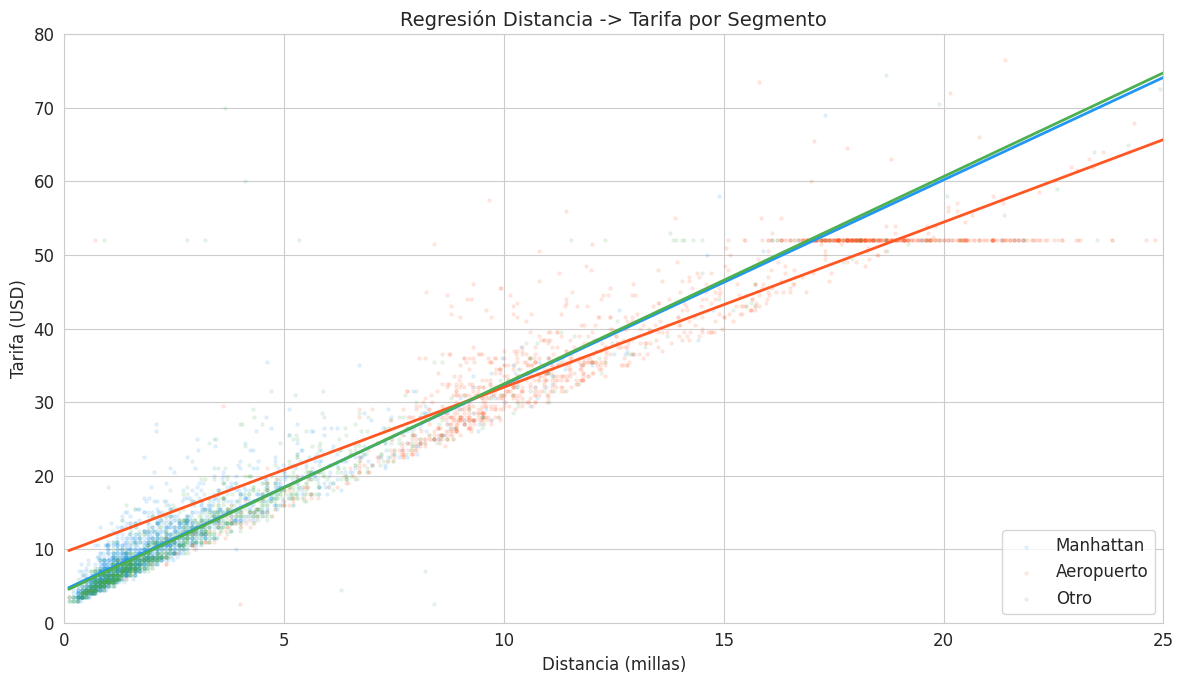

In [19]:
# Regresión por segmento
fig, ax = plt.subplots(figsize=(12, 7))

for seg, color in zip(['Manhattan', 'Aeropuerto', 'Otro'],
                       ['#2196F3', '#FF5722', '#4CAF50']):
    data = df[df['segment'] == seg].sample(n=min(2000, len(df[df['segment'] == seg])),
                                            random_state=42)
    sns.regplot(data=data, x='trip_distance', y='fare_amount',
                scatter_kws={'alpha': 0.1, 's': 5, 'color': color},
                line_kws={'linewidth': 2, 'color': color},
                ci=None, ax=ax, label=seg)

ax.set_xlim(0, 25)
ax.set_ylim(0, 80)
ax.set_title('Regresión Distancia -> Tarifa por Segmento', fontsize=14)
ax.set_xlabel('Distancia (millas)')
ax.set_ylabel('Tarifa (USD)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

**Interpretación de las regresiones por segmento:**
- Las **pendientes** difieren entre segmentos: Manhattan tiene una pendiente más pronunciada (más caro por milla)
- Los viajes al aeropuerto pueden mostrar una pendiente más plana debido a las tarifas fijas
- El **intercepto** refleja la tarifa base (mínimo que se paga al subir al taxi)

---
## Resumen del notebook

### ¿Qué determina el costo de un viaje?

| Factor | Impacto | Correlación |
|--------|---------|-------------|
| **Distancia** | Principal determinante | Alta (>0.8) |
| **Duración** | Segundo factor más importante | Moderada-Alta |
| **Zona** | Manhattan más caro por milla | Significativo |
| **Hora del día** | Horas pico más caras por milla | Moderado |
| **Nocturno** | Recargo modesto | Bajo |
| **Pasajeros** | Sin impacto significativo | Muy bajo |

### Siguientes pasos
- Notebook 05: Visualización geoespacial para ver estos patrones en un mapa
- Notebook 06: Dashboards interactivos con Plotly para explorar estas relaciones dinámicamente